In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/KeepCoding/NLP/Práctica

/content/drive/MyDrive/KeepCoding/NLP/Práctica


Se monta Google Drive en Colab para trabajar directamente sobre los archivos almacenados en Drive y evitar tener que subir datasets manualmente en cada sesión. Después se cambia el directorio de trabajo a la carpeta de la práctica.

In [3]:
import pandas as pd
import gzip

def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield eval(l)

def getDF(path):
  i = 0
  df = {}
  for d in parse(path):
    df[i] = d
    i += 1
  return pd.DataFrame.from_dict(df, orient='index')

In [24]:
df_reviews = getDF('Data/reviews_Sports_and_Outdoors_5.json.gz')

# Descarga y exploración del corpus

In [25]:
print(len(df_reviews))

296337


In [26]:
df_reviews.head(5)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AIXZKN4ACSKI,1881509818,David Briner,"[0, 0]",This came in on time and I am veru happy with ...,5.0,Woks very good,1390694400,"01 26, 2014"
1,A1L5P841VIO02V,1881509818,Jason A. Kramer,"[1, 1]",I had a factory Glock tool that I was using fo...,5.0,Works as well as the factory tool,1328140800,"02 2, 2012"
2,AB2W04NI4OEAD,1881509818,J. Fernald,"[2, 2]",If you don't have a 3/32 punch or would like t...,4.0,"It's a punch, that's all.",1330387200,"02 28, 2012"
3,A148SVSWKTJKU6,1881509818,"Jusitn A. Watts ""Maverick9614""","[0, 0]",This works no better than any 3/32 punch you w...,4.0,It's a punch with a Glock logo.,1328400000,"02 5, 2012"
4,AAAWJ6LW9WMOO,1881509818,Material Man,"[0, 0]",I purchased this thinking maybe I need a speci...,4.0,"Ok,tool does what a regular punch does.",1366675200,"04 23, 2013"


#### A continuación se realizará una exploración previa de las reviews, ya que el objetivo es transformar la puntuación por estrellas en una variable de sentimiento binaria: positivo o negativo.

#### En concreto, se analizarán manualmente aproximadamente 20 reviews de 3 estrellas para comprobar si este tipo de valoraciones reflejan un sentimiento más cercano al positivo, al negativo o si deberían tratarse como una clase neutral.

In [27]:
count = 0

for indice, review in df_reviews.iterrows():
    if review["overall"] == 3.0:
        print(review["reviewText"])
        print("--------------------------------------------------")

        count += 1

        if count == 10:
            break

It's cheaply made but does what it is supposed to do. Wish it was USB rechargeable. I don't think it will survive a monsoon but light rain it can handle.
--------------------------------------------------
Bought this for my wife as a tool to use to do mild exercises while she is going through chemotherapy.  She is 5&#8217;6&#8221; and has a hard time, no; she can&#8217;t use the cables for most of the exercises because the cables are too long. She has to double over the cables so the length is not too long.  This would be fine if there was a second door and ankle attachment, but there is not! She does use one cable at a time and does find the construction very good.  The variety of band resistances are nice as well as the exercise instruction book.
--------------------------------------------------
I have had these for about a week now... and i am afraid to use it at full potential...why?well from the first minute i took it out of the bag, i could tell it is made of cheap material...it

#### Tras revisar manualmente diferentes reviews de 3 estrellas, se observa que muchas de ellas contienen críticas, problemas de calidad o experiencias de uso parcialmente negativas, aunque el producto cumpla mínimamente su función.

#### Por este motivo, las reviews de 3 estrellas se incluirán dentro de la clase negativa. Esta decisión permite simplificar el problema de clasificación binaria y aumentar el número de ejemplos negativos disponibles para el entrenamiento del modelo.
#### No obstante, debe tenerse en cuenta que este tipo de reviews presentan un sentimiento más ambiguo, por lo que podrían introducir cierto ruido en el proceso de clasificación.
#### Además, la muestra de reviews analizada manualmente es relativamente pequeña, por lo que esta decisión se basa únicamente en una exploración preliminar y no en un análisis estadístico completo del corpus.

In [28]:
def label_sentiment(row):
    if row['overall'] < 4:
        return 0
    else:
        return 1

In [29]:
df_reviews['sentiment_label'] = df_reviews.apply(lambda row: label_sentiment(row), axis=1)

In [30]:
df_reviews.head(5)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,sentiment_label
0,AIXZKN4ACSKI,1881509818,David Briner,"[0, 0]",This came in on time and I am veru happy with ...,5.0,Woks very good,1390694400,"01 26, 2014",1
1,A1L5P841VIO02V,1881509818,Jason A. Kramer,"[1, 1]",I had a factory Glock tool that I was using fo...,5.0,Works as well as the factory tool,1328140800,"02 2, 2012",1
2,AB2W04NI4OEAD,1881509818,J. Fernald,"[2, 2]",If you don't have a 3/32 punch or would like t...,4.0,"It's a punch, that's all.",1330387200,"02 28, 2012",1
3,A148SVSWKTJKU6,1881509818,"Jusitn A. Watts ""Maverick9614""","[0, 0]",This works no better than any 3/32 punch you w...,4.0,It's a punch with a Glock logo.,1328400000,"02 5, 2012",1
4,AAAWJ6LW9WMOO,1881509818,Material Man,"[0, 0]",I purchased this thinking maybe I need a speci...,4.0,"Ok,tool does what a regular punch does.",1366675200,"04 23, 2013",1


In [31]:
df_reviews['sentiment_label'].value_counts()

,count
sentiment_label,
1,253017
0,43320


In [32]:
df_reviews['reviewText'].isna().sum()

np.int64(0)

In [33]:
# Eliminamos reviews vacías o nulas antes del balanceo
df_reviews = df_reviews.dropna(subset=["reviewText"])
df_reviews = df_reviews[df_reviews["reviewText"].str.strip() != ""]
df_reviews = df_reviews.reset_index(drop=True)

#### Durante la importación del dataset procesado desde el archivo CSV se detectó
#### una discrepancia en el número de reviews disponibles para el preprocesado.

#### Inicialmente, algunas reviews estaban siendo interpretadas como valores
#### nulos (`NaN`) al cargar el CSV con `pd.read_csv()`. Tras revisar el problema,
#### se comprobó que dichas filas no contenían valores nulos reales, sino
#### cadenas vacías (`""`) que pandas convertía automáticamente en `NaN`.

#### Para evitar este comportamiento, el dataset fue cargado utilizando el
#### parámetro `keep_default_na=False`. Además, se decidió eliminar previamente
#### aquellas reviews vacías o compuestas únicamente por espacios antes de
#### realizar el balanceo y el preprocesado del corpus.

#### De esta forma se garantiza una mayor consistencia en el pipeline de NLP y
#### se evitan posibles errores durante las etapas posteriores de entrenamiento
#### y vectorización del texto.

In [34]:
# Separamos reviews positivas y negativas

negative_df = df_reviews[df_reviews['sentiment_label'] == 0]
positive_df = df_reviews[df_reviews['sentiment_label'] == 1]

# Seleccionamos 5000 muestras de cada clase

negative_sample = negative_df.sample(n=5000, random_state=42)
positive_sample = positive_df.sample(n=5000, random_state=42)

# Unimos ambos datasets balanceados

df_reviews_filtered = pd.concat([negative_sample, positive_sample])

In [35]:
print(len(df_reviews_filtered))

10000


In [36]:
df_reviews_filtered = df_reviews_filtered.reset_index(drop=True)

In [38]:
df_reviews_filtered.head(5)

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,sentiment_label
0,A3MCKE2J5F9XO9,B000R845C4,ME,"[0, 0]",Stripper clips. Glorious stripper clips. The...,3.0,Stripper clips...,1374019200,"07 17, 2013",0
1,A7OHBCMRMNVPR,B001B8ONZI,Paul B.,"[0, 0]",Purchases two pair of these. Both pair worked ...,3.0,50%,1332115200,"03 19, 2012",0
2,AEG9SBQ1UETBD,B0015TT3V2,R. Wasilewski,"[0, 1]",I put this on my fox float 32 and honestly not...,3.0,Not sure it really works,1380067200,"09 25, 2013",0
3,A3A2XWUX499M57,B000DZD3FQ,Mikhael,"[0, 0]",It's a good computer. My rating is impacted by...,2.0,Programming is a pain. Easy to accidentally cl...,1356912000,"12 31, 2012",0
4,A43Y8KFO5JK5P,B002HU086C,"Ahmed Syed ""Genus: Constrictus realtight and ...","[1, 3]",These are heavy duty stakes which certainly ar...,1.0,Good but cheap plastic,1369699200,"05 28, 2013",0


In [62]:
df_reviews_filtered.to_csv("df_reviews_filtered.csv", index=False)

#### Seleccionamos únicamente las columnas relevantes para el análisis de sentimiento:
- reviewText -> texto de la review
- overall -> puntuación en estrellas

#### Posteriormente convertimos el DataFrame a diccionario utilizando orient='index', manteniendo la estructura fila -> datos. Esto facilita trabajar posteriormente con las reviews y etiquetas.

In [40]:
reviews_dict=df_reviews_filtered[['reviewText','sentiment_label']].to_dict("index")

In [41]:
print(reviews_dict)

Output hidden; open in https://colab.research.google.com to view.

In [42]:
print(reviews_dict.get(9999))

{'reviewText': 'Good ammo belt for the price especially. I cut some off it as was too big as others have reported but no big deal as holds 30 30 shells great and being new even holds my 357 ammo shells --so far anyway till it stretches out maybe but happy with it for the price.', 'sentiment_label': 1}


## Cardinalidad del vocabulario

In [43]:
from nltk.tokenize import TreebankWordTokenizer

def get_vocabulary_cardinality(reviews_dict):
    tokenizer = TreebankWordTokenizer()
    vocabulary = set()

    for indice, review in reviews_dict.items():
        text = review["reviewText"]

        if isinstance(text, str):
            tokens = tokenizer.tokenize(text.lower())
            vocabulary.update(tokens)

    return len(vocabulary), vocabulary

In [44]:
vocab_size, vocabulary = get_vocabulary_cardinality(reviews_dict)

print("Cardinalidad del vocabulario:", vocab_size)

Cardinalidad del vocabulario: 40237


## Distribución de reviews por número de estrellas

In [45]:
df_reviews["overall"].value_counts()

,count
overall,
5.0,188132
4.0,64785
3.0,24064
2.0,10199
1.0,9034


#### Aunque el problema final lo he planteado como clasificación binaria de sentimiento, se analiza previamente la distribución original por número de estrellas para conocer la estructura inicial del corpus antes de haber agrupado las valoraciones en positivas y negativas.

## Nº de reviews positivas y negativas

In [46]:
df_reviews_filtered["sentiment_label"].value_counts()

,count
sentiment_label,
0,5000
1,5000


#### El dataset final utilizado para el entrenamiento se encuentra balanceado,contando con 5000 reviews negativas y 5000 positivas.

#### Este balanceo se ha realizado intencionadamente para evitar posibles sesgos hacia una clase mayoritaria durante el entrenamiento del modelo de clasificación supervisada.

## N-grams más frecuentes

In [47]:
!pip install nltk

In [48]:
from nltk import ngrams
from nltk.probability import FreqDist

In [49]:
all_reviews_text = " ".join(
    review["reviewText"]
    for review in reviews_dict.values()
)

In [50]:
tokenizer = TreebankWordTokenizer()
words_nltk = tokenizer.tokenize(all_reviews_text.lower())

In [51]:
words_nltk[:10]

['stripper',
 'clips.',
 'glorious',
 'stripper',
 'clips.',
 'they',
 'chew',
 'up',
 'your',
 'fingers']

In [52]:
bigrams_ = list(ngrams(words_nltk, 2))
trigrams_ = list(ngrams(words_nltk, 3))

In [53]:
bigrams_[:10]

[('stripper', 'clips.'),
 ('clips.', 'glorious'),
 ('glorious', 'stripper'),
 ('stripper', 'clips.'),
 ('clips.', 'they'),
 ('they', 'chew'),
 ('chew', 'up'),
 ('up', 'your'),
 ('your', 'fingers'),
 ('fingers', 'and')]

In [55]:
trigrams_[:10]

[('stripper', 'clips.', 'glorious'),
 ('clips.', 'glorious', 'stripper'),
 ('glorious', 'stripper', 'clips.'),
 ('stripper', 'clips.', 'they'),
 ('clips.', 'they', 'chew'),
 ('they', 'chew', 'up'),
 ('chew', 'up', 'your'),
 ('up', 'your', 'fingers'),
 ('your', 'fingers', 'and'),
 ('fingers', 'and', 'can')]

In [56]:
bg_freq = FreqDist(bigrams_)
tg_freq = FreqDist(trigrams_)

In [57]:
bg_freq.most_common(10)

[((',', 'but'), 4171),
 ((',', 'and'), 3850),
 (('of', 'the'), 3780),
 (('it', "'s"), 2899),
 ((',', 'i'), 2771),
 (('on', 'the'), 2761),
 (('in', 'the'), 2737),
 (('it', 'is'), 2553),
 (('i', 'have'), 2398),
 (('if', 'you'), 2249)]

In [58]:
tg_freq.most_common(10)

[(('&', '#', '34'), 1354),
 (('#', '34', ';'), 1354),
 (('i', 'do', "n't"), 726),
 ((',', 'but', 'i'), 691),
 (('this', 'is', 'a'), 641),
 ((',', 'but', 'it'), 569),
 (('a', 'lot', 'of'), 451),
 (('it', "'s", 'a'), 410),
 ((',', 'and', 'the'), 407),
 (('!', '!', '!'), 405)]

#### Los n-grams más frecuentes obtenidos en esta primera exploración contienen principalmente signos de puntuación, contracciones y términos poco relevantes.

#### Esto ocurre debido a que el corpus todavía no ha pasado por una etapa de preprocesado de texto. Por tanto, aún existen elementos como signos de puntuación, caracteres especiales y tokens poco informativos que afectan a la calidad de los n-grams generados.

#### Más adelante, tras aplicar el preprocesado correspondiente, se volverá a realizar esta exploración para obtener n-grams más representativos y útiles para el análisis de sentimiento.

## Nubes de palabras

In [59]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [60]:
def plot_word_cloud(text):
    wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(' '.join(text))
    plt.figure(figsize=(12,6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

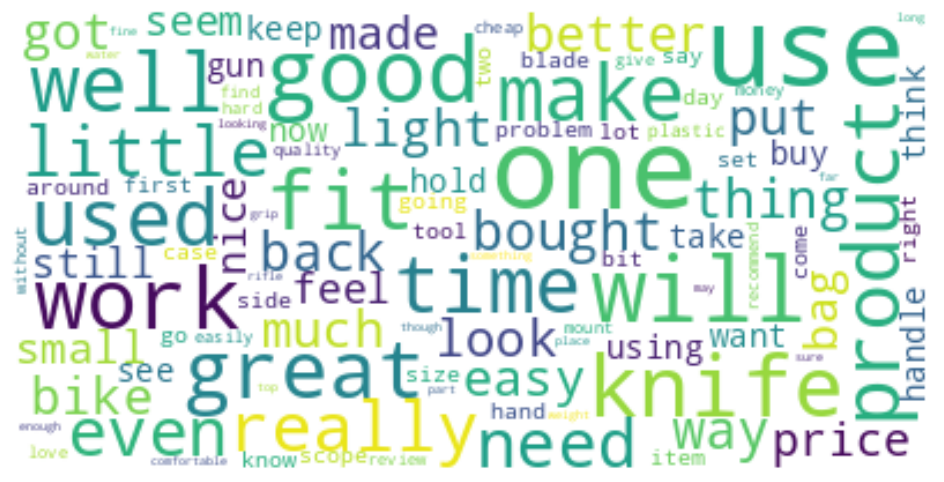

In [61]:
words_list = all_reviews_text.lower().strip().split()
plot_word_cloud(words_list)

#### La nube de palabras permite visualizar los términos más frecuentes del corpus de manera rápida e intuitiva.

#### Además de servir como exploración inicial del dataset, esta representación puede ayudar a detectar posibles stopwords o términos poco informativos que podrían eliminarse durante la etapa de preprocesado.
#### No obstante, debe tenerse cuidado con eliminar palabras frecuentes que sí puedan aportar información relevante sobre el sentimiento, como por ejemplo términos positivos o negativos asociados a opiniones de usuarios.